### Bank Marketing Classification 
Need to predict if the customer take term deposit or not based on the features and latest campaign

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')



Setup complete.


---
## Data Loading and Inspection
- Data Loading and describingg the data
- Checking the null values

In [7]:
# Load the data

data = pd.read_csv('bank-marketing-dataset-full.csv',sep=';')
print(f"Number of columns : {data.shape[1]}")
print(f"Number of rows : {data.shape[0]}")
data.head(5)

Number of columns : 21
Number of rows : 41188


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [9]:
# Null Value handling 
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [11]:
numerical_columns = data.select_dtypes(include='number').columns

In [12]:
categorical_columns = data.select_dtypes(include='object').columns

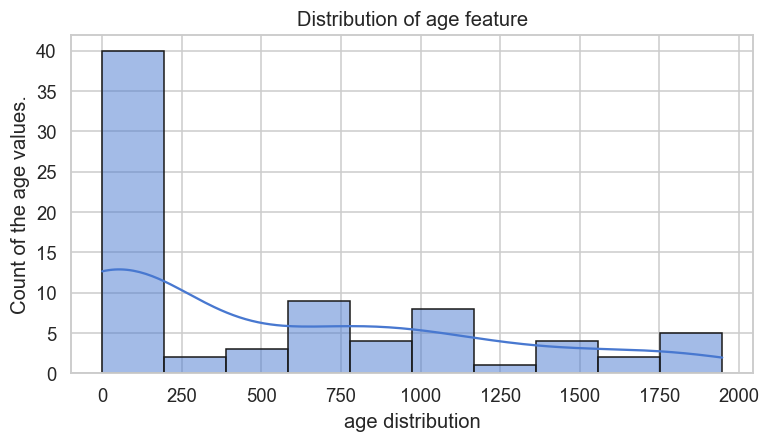

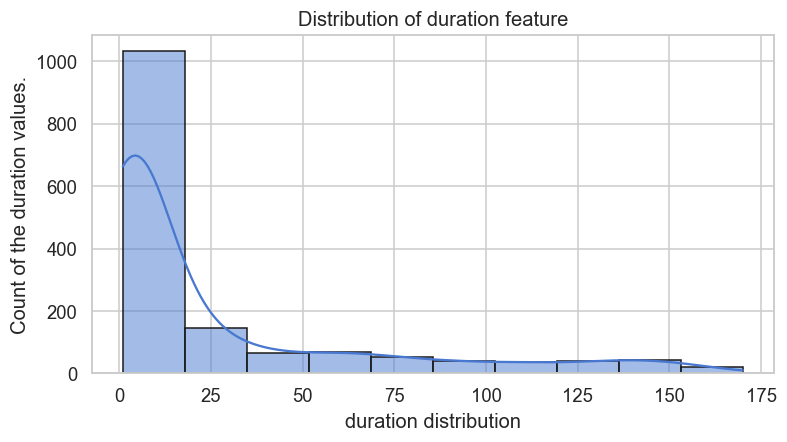

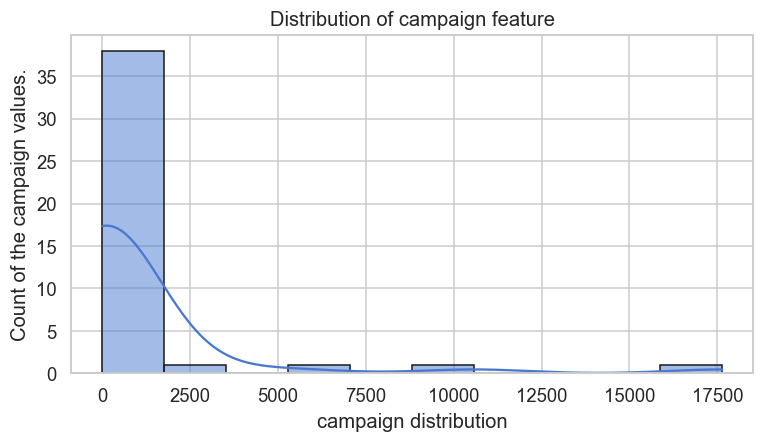

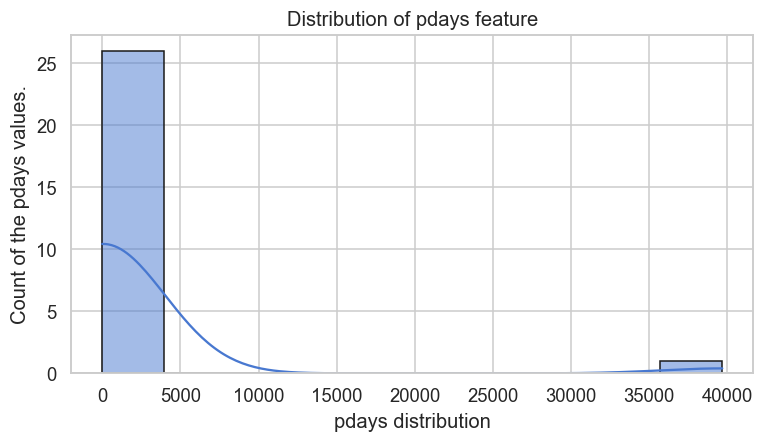

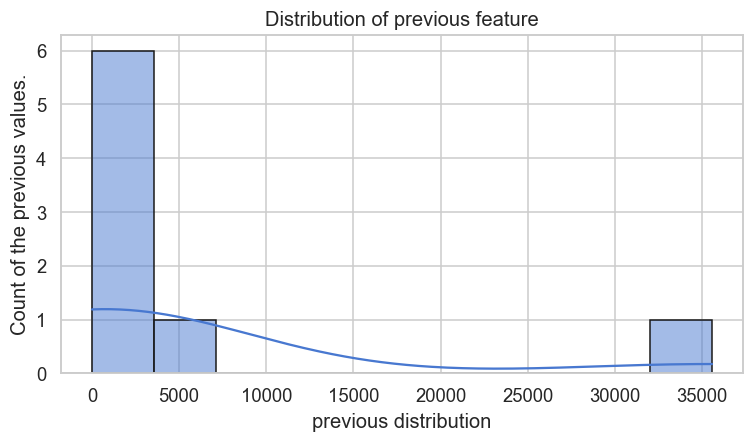

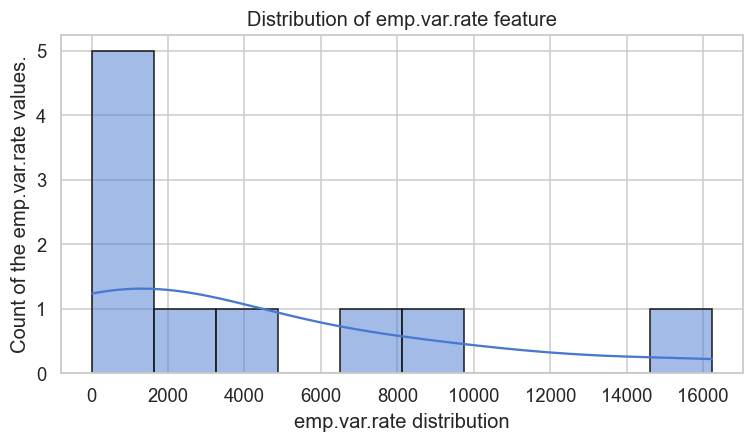

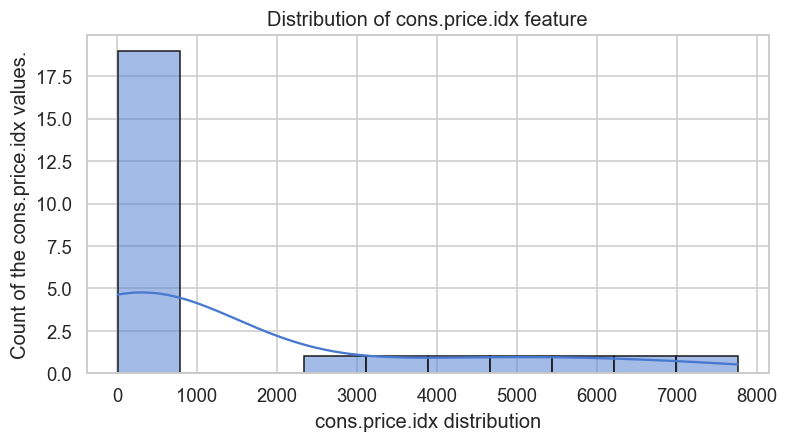

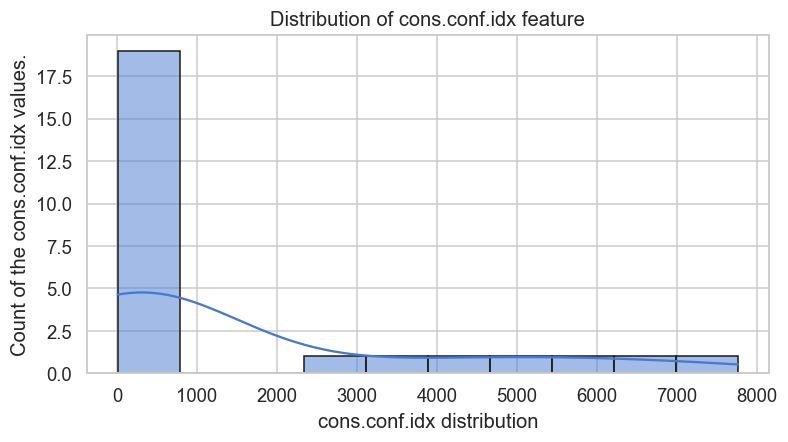

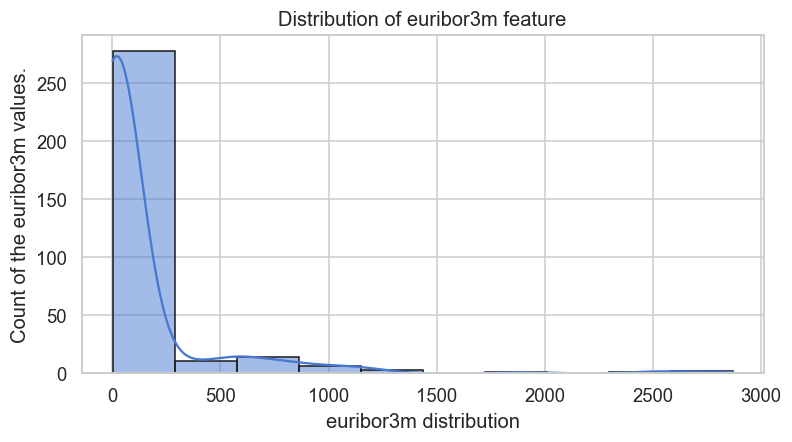

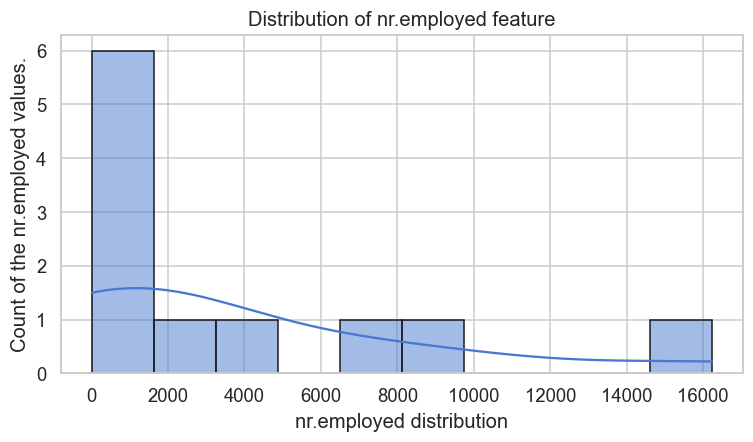

In [13]:
# EDA on numerical values

for columns in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=data[columns].value_counts(), bins=10, edgecolor='k', kde=True)
    plt.title(f"Distribution of {columns} feature")
    plt.xlabel(f"{columns} distribution")
    plt.ylabel(f"Count of the {columns} values.")

    
    

---
## 2 — Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

<Axes: xlabel='y'>

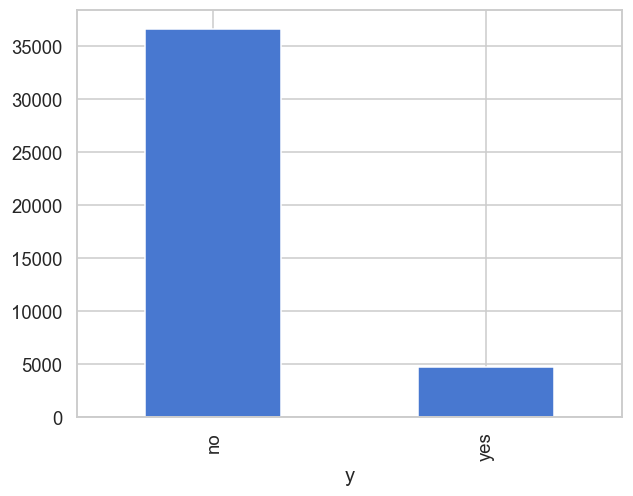

In [14]:
data['y'].value_counts().plot(kind='bar')

y
no     36548
yes     4640
Name: count, dtype: int64

Imbalance ratio (no:yes): 7.9:1


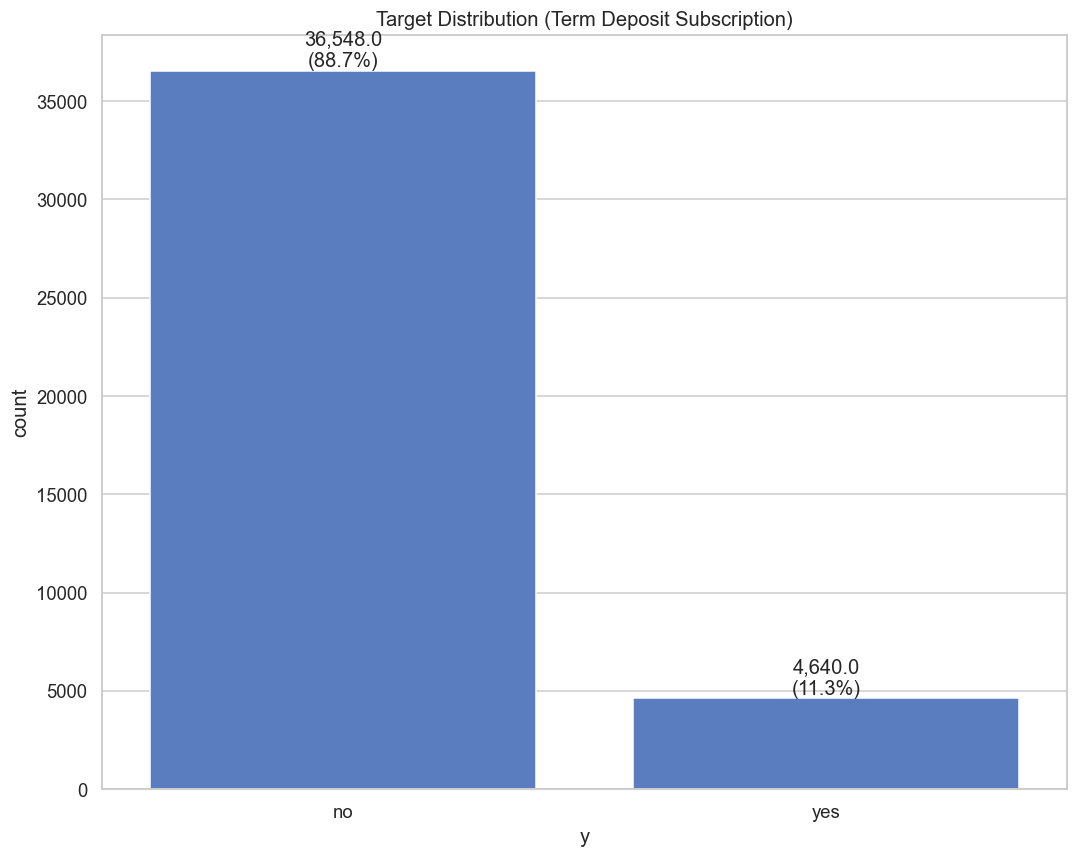

In [15]:
target_count = data['y'].value_counts()
print(target_count)

print(f'\nImbalance ratio (no:yes): {target_count["no"] / target_count["yes"]:.1f}:1')


fig, ax = plt.subplots(figsize=(10, 8))
sns.countplot(x='y', data=data, order=['no', 'yes'], ax=ax)
ax.set_title('Target Distribution (Term Deposit Subscription)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(data)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [16]:
data.head(30)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [17]:
unknown_values  = data.isin(['unknown']).sum()
unknown_values_count  = unknown_values[unknown_values > 0].sort_values(ascending=False)
print(unknown_values_count)
print(f"Count of Rows having one unknown value : {data.isin(['unknown']).any(axis=1).sum()}")

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64
Count of Rows having one unknown value : 10700


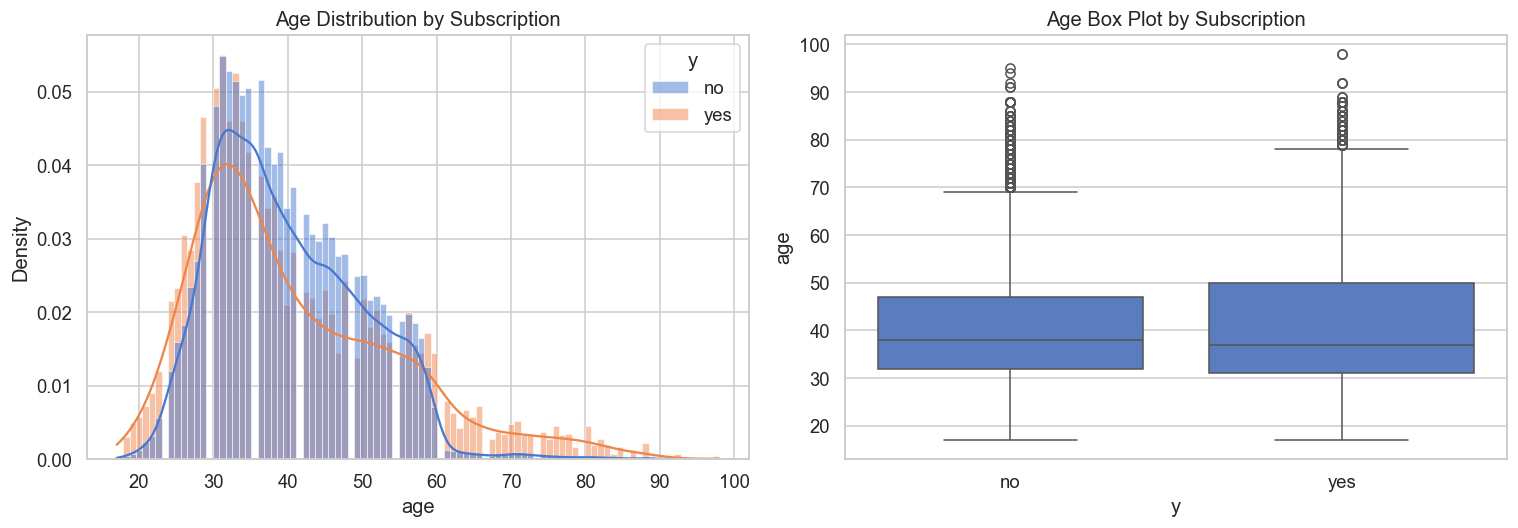

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=data, x='age', hue='y', kde=True, ax=axes[0], stat='density', common_norm=False)
axes[0].set_title('Age Distribution by Subscription')

sns.boxplot(data=data, x='y', y='age', order=['no', 'yes'], ax=axes[1])
axes[1].set_title('Age Box Plot by Subscription')

plt.tight_layout()
plt.show()

### Job type vs Subscription rate

Text(0, 0.5, 'Average Subscribed')

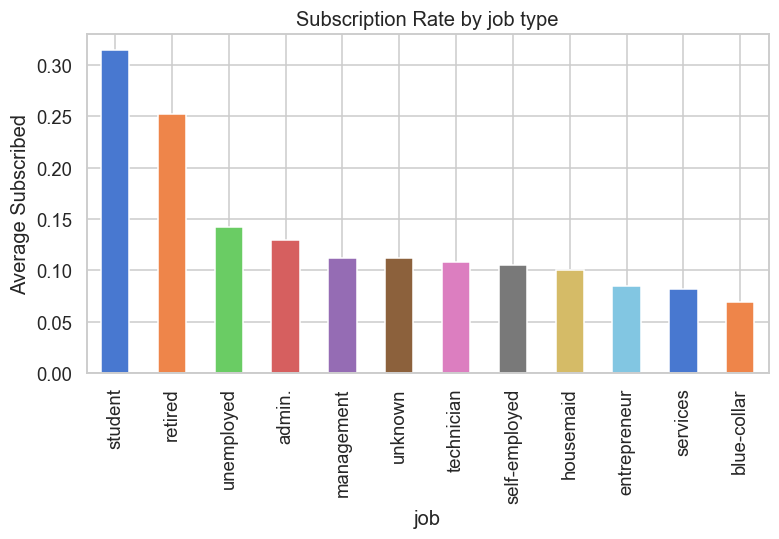

In [19]:
job_sub = data.groupby('job')['y'].apply(lambda x : (x == 'yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,4))
job_sub.plot(kind='bar', ax=ax, color= sns.color_palette('muted'))
ax.set_title("Subscription Rate by job type")
ax.set_ylabel("Average Subscribed")

### Other key relationships with other columns

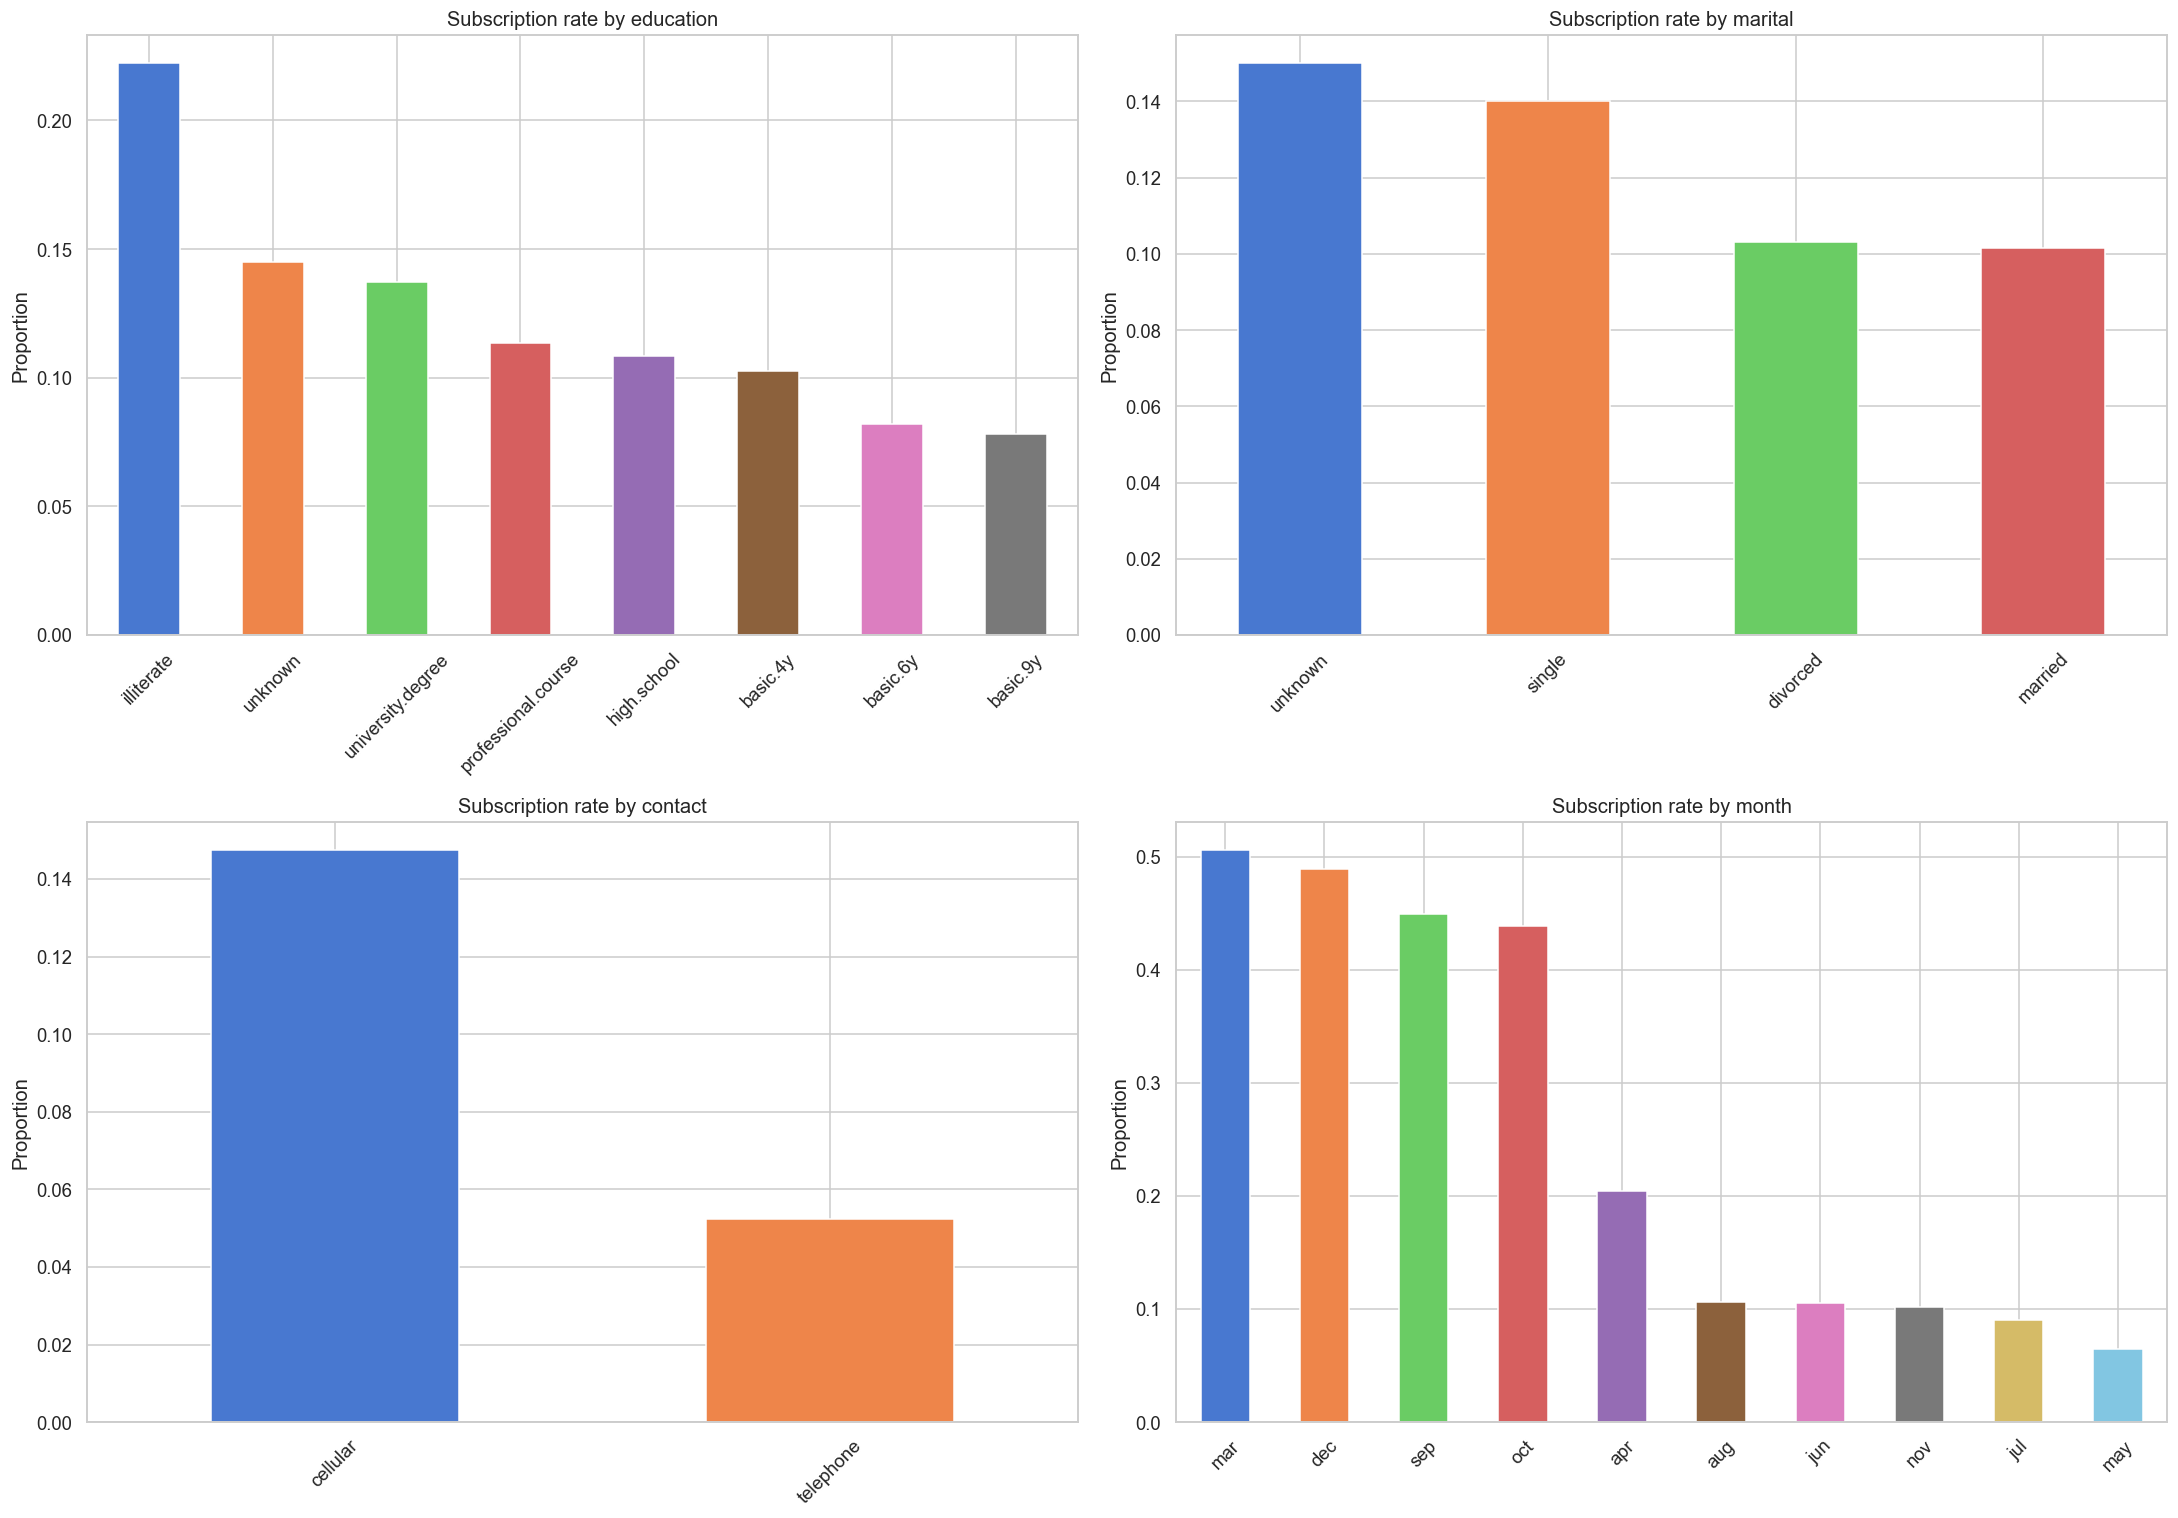

In [20]:
fig, ax = plt.subplots(2, 2, figsize = (20, 14))

for ax, col in zip(ax.flatten(), ['education', 'marital', 'contact', 'month']):
    sub_feature = data.groupby(col)['y'].apply(lambda x : (x == 'yes').mean()).sort_values(ascending=False)
    sub_feature.plot(kind='bar', ax=ax, color=sns.color_palette('muted'))
    ax.set_title(f"Subscription rate by {col}")
    ax.set_ylabel(f"Proportion")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [21]:
cat_cols = data.select_dtypes(include='object').columns.drop('y').tolist()
num_cols = data.select_dtypes(include='number').columns.tolist()

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numeric ({len(num_cols)}): {num_cols}')

Categorical (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numeric (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Correlation HeatMap

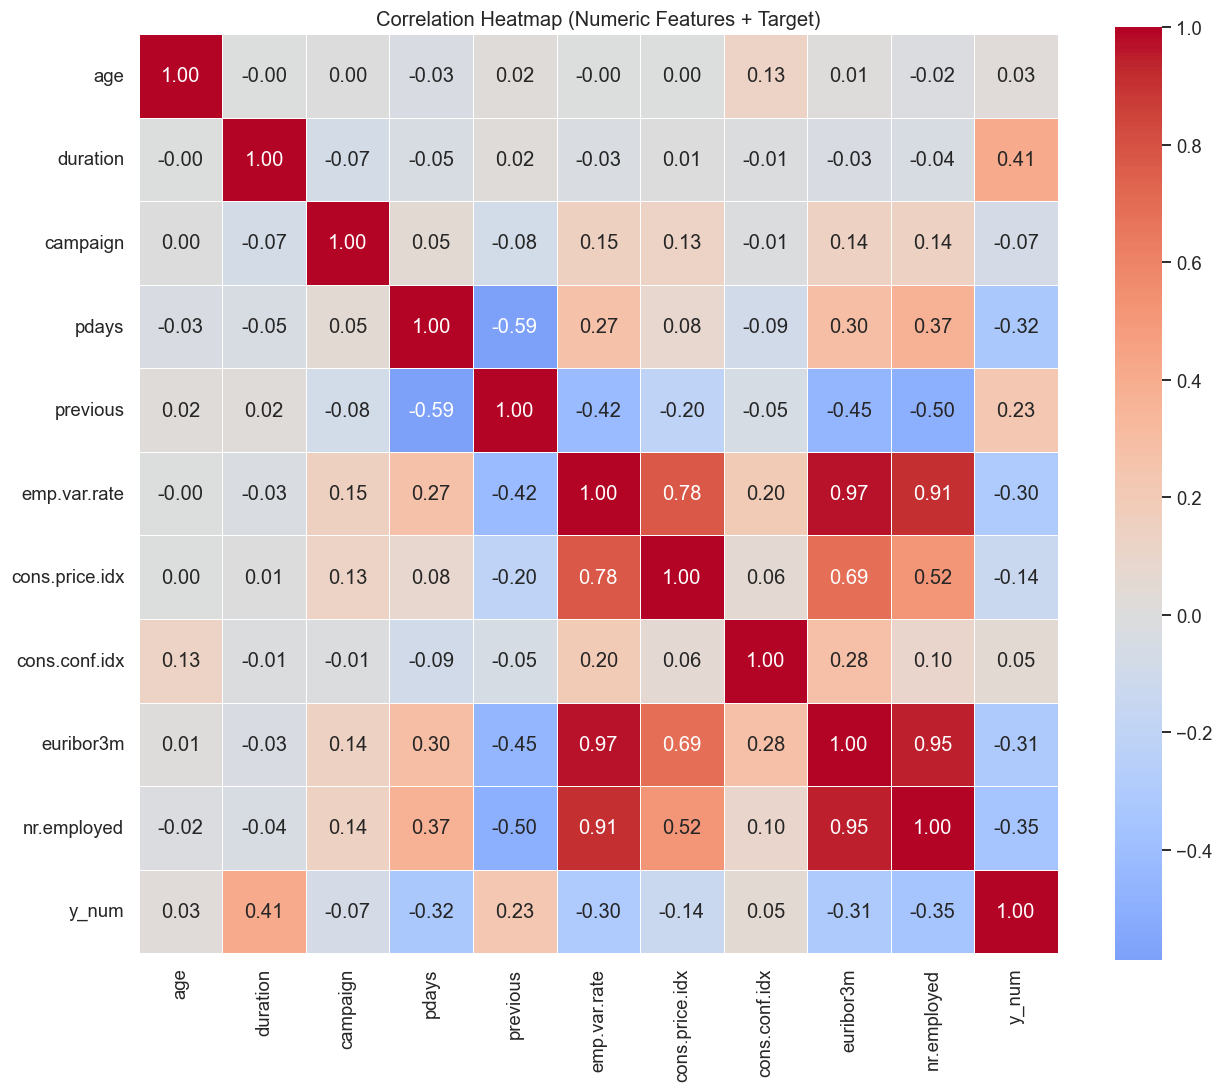

In [22]:
data_corr = data.copy()
data_corr['y_num'] = (data_corr['y'] == 'yes').astype(int)

corr = data_corr[num_cols + ['y_num']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap (Numeric Features + Target)')
plt.tight_layout()
plt.show()

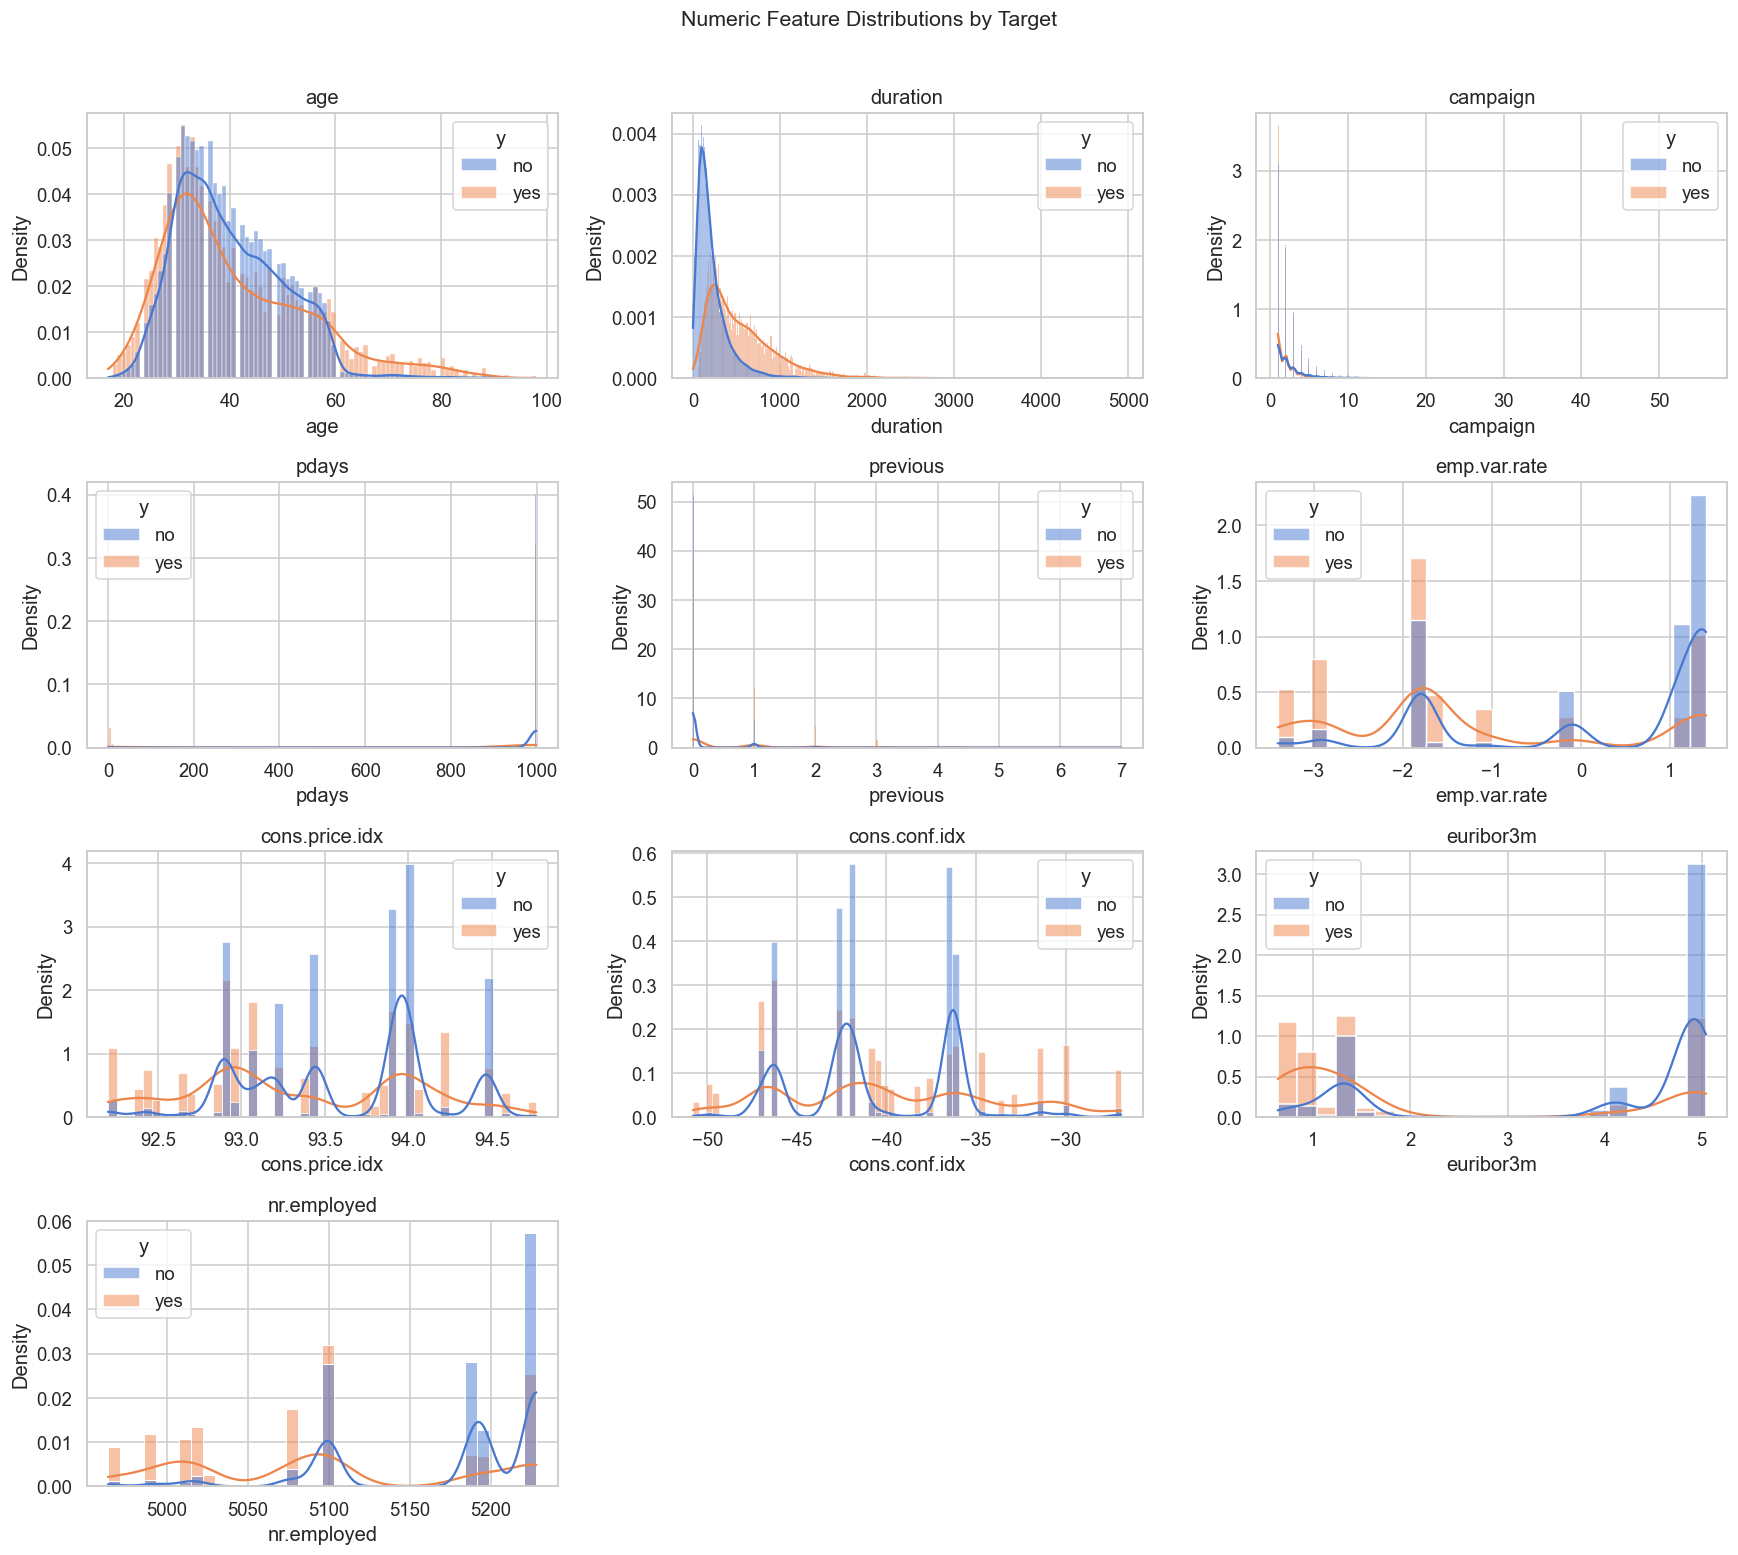

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes_flat = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=data, x=col, hue='y', kde=True, ax=axes_flat[i],
                 stat='density', common_norm=False, alpha=0.5)
    axes_flat[i].set_title(col)

for j in range(len(num_cols), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Target', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**EDA Summary:**
- Class imbalance is ~88:12. Models must account for this.
- `duration` is the strongest predictor but must be dropped for a realistic model (only known after the call).
- Older and younger customers (students, retired) have higher subscription rates.
- `euribor3m`, `emp.var.rate`, `nr.employed` are strongly correlated with each other and with the target — macroeconomic conditions matter.
- `pdays = 999` dominates — this feature is effectively binary (contacted before or not).
- `default` has very few "yes" values and many "unknown".

---
## 3 — Preprocessing & Baseline Models

### 3.1 Feature Engineering & Cleaning

In [24]:
model_data = data.drop(columns=['duration'])
model_data['y'] = (model_data['y'] == 'yes').astype(int)

# Keep "unknown" as its own category - may carry predictive signal
print('Keeping "unknown" as its own category for one-hot encoding.')
print(f'Shape after dropping duration: {model_data.shape}')

Keeping "unknown" as its own category for one-hot encoding.
Shape after dropping duration: (41188, 20)


### 3.2 Train & Test Split

In [25]:
num_col_model = [c for c in numerical_columns if c != 'duration']
cat_col_model = categorical_columns
x = model_data.drop(columns=['y'])
y = model_data['y']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=SEED, test_size=0.3, stratify=y)
print(f"X_Train : {x_train.shape} x_test : {x_test.shape}")
print(f"Training Target Distribution : {y_train.value_counts(normalize = True)}")

X_Train : (28831, 19) x_test : (12357, 19)
Training Target Distribution : y
0    0.887343
1    0.112657
Name: proportion, dtype: float64


In [26]:
print(f"Training Target Distribution : {y_train.value_counts(normalize=True)}")
print(f"Testing Target Distribution : {y_test.value_counts(normalize=True)}")

Training Target Distribution : y
0    0.887343
1    0.112657
Name: proportion, dtype: float64
Testing Target Distribution : y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


In [27]:
# cat_col_model = list(cat_col_model).remove('y')

cat_col_model = cat_col_model.drop('y')

cat_col_model


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

### 3.3 Preprocessing Pipeline Building

In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_col_model),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary', sparse_output=False), cat_col_model)
    ]
)

### 3.4 Baseline Modeling

In [29]:
def evaluate_models(name, model, x_tr, y_tr, x_tst, y_tst):
    """Fit model, predict, return metrics dict."""
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_tst)
    y_prob = model.predict_proba(x_tst) if hasattr(model, 'predict_proba') else None

    metrics = {
        'Model': name,
        "Accuracy" : accuracy_score(y_tst, y_pred),
        "precision" : precision_score(y_tst, y_pred),
        "recall" : recall_score(y_tst, y_pred),
        "Accuracy" : accuracy_score(y_tst, y_pred),
        'F1': f1_score(y_tst, y_pred),
        'ROC-AUC': roc_auc_score(y_tst, y_prob[:, 1]) if y_prob is not None else np.nan,
    }

    return metrics, y_pred, y_prob

baseline = {
    'LogisticRegression' : Pipeline([
        ('pre', preprocessor),
        ('clf', LogisticRegression(max_iter=1000, random_state=SEED))
    ]),
    'DecisionTreeClassifier' : Pipeline([
        ('pre', preprocessor),
        ('clf', DecisionTreeClassifier(random_state=SEED))
    ]),
    'GaussianNB' : Pipeline([
        ('pre', preprocessor),
        ('clf', GaussianNB())
    ])
}

results = []
pred = {}
prob = {}

for name, pipe in baseline.items():
    m, ypred, yprob = evaluate_models(name, pipe, x_train, y_train, x_test, y_test)
    results.append(m)
    pred[name] = ypred
    prob[name] = yprob
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(3)

LogisticRegression: F1=0.334, ROC-AUC=0.803
DecisionTreeClassifier: F1=0.327, ROC-AUC=0.626
GaussianNB: F1=0.421, ROC-AUC=0.773


,Accuracy,precision,recall,F1,ROC-AUC
Model,,,,,
LogisticRegression,0.902,0.701,0.219,0.334,0.803
DecisionTreeClassifier,0.839,0.308,0.348,0.327,0.626
GaussianNB,0.810,0.320,0.616,0.421,0.773


In [30]:
x_train.shape

(28831, 19)

In [31]:
y_train.shape

(28831,)

In [32]:
x_test.shape

(12357, 19)

In [33]:
y_test.shape

(12357,)

---

# 4 Advanced Modeling & Imbalance Handling
## 4.1 Advanced models with class weights

In [34]:
spw = (y_train == 0).sum() / (y_train == 1).sum()

advance_models = {
    'Random Forest (Balanced)' : Pipeline([
        ('pre', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED, n_jobs=-1))
    ]),
    'Gradient Descent' : Pipeline([
        ('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=SEED))
    ]),
    'XGBoost (Weighted)' : Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(n_estimator=200, learning_rate = 0.1, max_depth = 5, scale_pos_weight = spw, random_seed = SEED, eval_metrics = 'logloss'))
    ])
}





for name, pipe in advance_models.items():
    m, ypre, ypro = evaluate_models(name, pipe, x_train, y_train, x_test, y_test)
    results.append(m)
    pred[name] = ypre
    prob[name] = ypro
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')
    
results_df = pd.DataFrame(results).set_index('Model')
results_df.round(3)


Random Forest (Balanced): F1=0.457, ROC-AUC=0.781
Gradient Descent: F1=0.381, ROC-AUC=0.808
XGBoost (Weighted): F1=0.481, ROC-AUC=0.811


,Accuracy,precision,recall,F1,ROC-AUC
Model,,,,,
LogisticRegression,0.902,0.701,0.219,0.334,0.803
DecisionTreeClassifier,0.839,0.308,0.348,0.327,0.626
GaussianNB,0.810,0.320,0.616,0.421,0.773
Random Forest (Balanced),0.875,0.448,0.467,0.457,0.781
Gradient Descent,0.900,0.632,0.273,0.381,0.808
XGBoost (Weighted),0.843,0.382,0.647,0.481,0.811


### 4.2 SMOTE OverSampling

- This is for target variable balancing or making the target variable values distributed in same portion

In [35]:
X_train_pre = preprocessor.fit_transform(x_train)
X_test_pre = preprocessor.transform(x_test)

In [36]:
smote = SMOTE(random_state=SEED)

x_train_smt, y_train_smt = smote.fit_resample(X_train_pre, y_train)

print(f"AFTER SMOTE : {pd.Series(y_train_smt).value_counts().to_dict()}")

AFTER SMOTE : {0: 25583, 1: 25583}


In [37]:
smote_model = {
    'Logistic Reg + SMOTE' : LogisticRegression(random_state=SEED, max_iter=1000),
    'Random Forest + SMOTE': RandomForestClassifier(random_state=SEED, n_estimators=300, n_jobs=-1)
}

for name, clf in smote_model.items():
    m, yp, ypr = evaluate_models(name, clf, x_train_smt, y_train_smt, X_test_pre, y_test)
    results.append(m)
    pred[name] = yp
    prob[name] = ypr
    print(f'{name}: F1={m["F1"]:.3f}, ROC-AUC={m["ROC-AUC"]:.3f}')


results_df = pd.DataFrame(results).set_index('Model')

results_df.round(3)

Logistic Reg + SMOTE: F1=0.458, ROC-AUC=0.802
Random Forest + SMOTE: F1=0.414, ROC-AUC=0.782


,Accuracy,precision,recall,F1,ROC-AUC
Model,,,,,
LogisticRegression,0.902,0.701,0.219,0.334,0.803
DecisionTreeClassifier,0.839,0.308,0.348,0.327,0.626
GaussianNB,0.810,0.320,0.616,0.421,0.773
Random Forest (Balanced),0.875,0.448,0.467,0.457,0.781
Gradient Descent,0.900,0.632,0.273,0.381,0.808
XGBoost (Weighted),0.843,0.382,0.647,0.481,0.811
Logistic Reg + SMOTE,0.825,0.352,0.654,0.458,0.802
Random Forest + SMOTE,0.888,0.505,0.351,0.414,0.782


In [38]:
# results_df = results_df.drop(axis=0, labels=['Logistic Reg + SMOTE', 'Random ForestSMOTE'])

In [39]:
results_df

,Accuracy,precision,recall,F1,ROC-AUC
Model,,,,,
LogisticRegression,0.901513,0.701149,0.219109,0.333881,0.803339
DecisionTreeClassifier,0.838553,0.308328,0.348420,0.327150,0.625516
GaussianNB,0.809501,0.320254,0.615661,0.421337,0.773171
Random Forest (Balanced),0.875132,0.447967,0.466954,0.457263,0.780744
Gradient Descent,0.900218,0.632280,0.272989,0.381335,0.807737
XGBoost (Weighted),0.842518,0.382428,0.647270,0.480790,0.810762
Logistic Reg + SMOTE,0.825281,0.351873,0.654454,0.457674,0.801780
Random Forest + SMOTE,0.888161,0.505165,0.351293,0.414407,0.781838


### 4.3 Cross Validation (5 - fold stratified)

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_models = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Random Forest (balanced)': Pipeline([('pre', preprocessor),
                                           ('clf', RandomForestClassifier(n_estimators=200,
                                                                          class_weight='balanced',
                                                                          random_state=SEED, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('pre', preprocessor),
                                    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                                       max_depth=5, random_state=SEED))]),
    'XGBoost (weighted)': Pipeline([
        ('pre', preprocessor),
        ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              scale_pos_weight=spw, random_state=SEED,
                              eval_metric='logloss'))
    ]),
}

cv_results = []
for name, pipe in cv_models.items():
    scores = cross_val_score(pipe, x_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results.append({'Model': name, 'CV ROC-AUC Mean': scores.mean(), 'CV ROC-AUC Std': scores.std()})
    print(f'{name}: CV ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}')

pd.DataFrame(cv_results).set_index('Model').round(4)

Logistic Regression: CV ROC-AUC = 0.7861 +/- 0.0110
Random Forest (balanced): CV ROC-AUC = 0.7720 +/- 0.0150
Gradient Boosting: CV ROC-AUC = 0.7912 +/- 0.0131
XGBoost (weighted): CV ROC-AUC = 0.7879 +/- 0.0131


,CV ROC-AUC Mean,CV ROC-AUC Std
Model,,
Logistic Regression,0.7861,0.0110
Random Forest (balanced),0.7720,0.0150
Gradient Boosting,0.7912,0.0131
XGBoost (weighted),0.7879,0.0131


### 4.3 Hyperparameter Tuning

In [41]:
tune_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', GradientBoostingClassifier(random_state=SEED))
])

param_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__max_depth': [3, 5, 7],
    'clf__subsample': [0.8, 1.0],
}

grid = GridSearchCV(tune_pipe, param_grid, cv=cv, scoring='roc_auc',
                    n_jobs=-1, verbose=1, refit=True)
grid.fit(x_train, y_train)

print(f'Best params: {grid.best_params_}')
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

best_model = grid.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 7, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Best CV ROC-AUC: 0.7981


In [42]:
y_pred_best = best_model.predict(x_test)
y_prob_best = best_model.predict_proba(x_test)[:, 1]

m_best = {
    'Model': 'Tuned GB (GridSearch)',
    'Accuracy': accuracy_score(y_test, y_pred_best),
    'precision': precision_score(y_test, y_pred_best),
    'recall': recall_score(y_test, y_pred_best),
    'F1': f1_score(y_test, y_pred_best),
    'ROC-AUC': roc_auc_score(y_test, y_prob_best),
}
results.append(m_best)
pred['Tuned GB (GridSearch)'] = y_pred_best
prob['Tuned GB (GridSearch)'] = y_prob_best

print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

              precision    recall  f1-score   support

          No       0.91      0.98      0.95     10965
         Yes       0.63      0.26      0.37      1392

    accuracy                           0.90     12357
   macro avg       0.77      0.62      0.66     12357
weighted avg       0.88      0.90      0.88     12357



---

# 5 Model Evaluation & Communication

### 5.1 Model Comparison Table

In [46]:
final_df = pd.DataFrame(results).set_index('Model')
final_df = final_df.sort_values('ROC-AUC', ascending=False)
final_df.style.format('{:.3f}').background_gradient(cmap='YlGn', axis=0)

,Accuracy,precision,recall,F1,ROC-AUC
Model,,,,,
Tuned GB (GridSearch),0.899,0.627,0.261,0.368,0.812
XGBoost (Weighted),0.843,0.382,0.647,0.481,0.811
Gradient Descent,0.900,0.632,0.273,0.381,0.808
LogisticRegression,0.902,0.701,0.219,0.334,0.803
Logistic Reg + SMOTE,0.825,0.352,0.654,0.458,0.802
Random Forest + SMOTE,0.888,0.505,0.351,0.414,0.782
Random Forest (Balanced),0.875,0.448,0.467,0.457,0.781
GaussianNB,0.810,0.320,0.616,0.421,0.773
DecisionTreeClassifier,0.839,0.308,0.348,0.327,0.626


### 5.2 ROC Curves

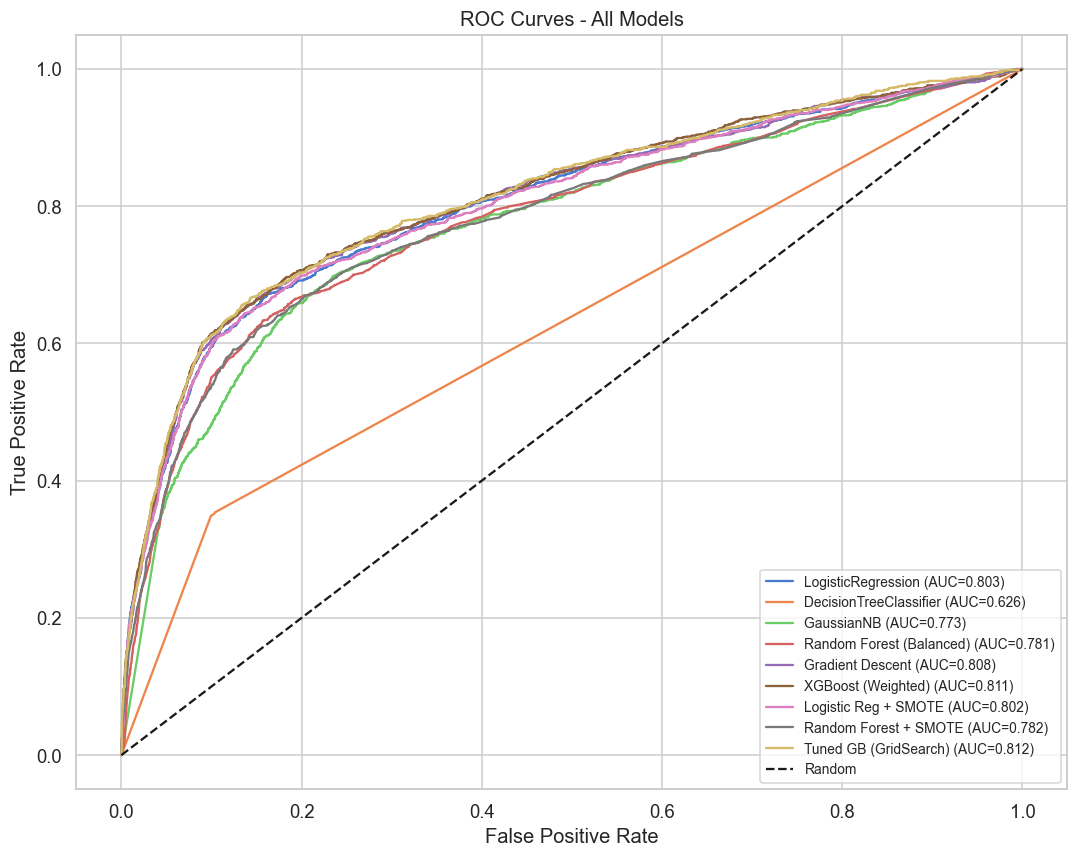

In [50]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, ypr in prob.items():
    if ypr is not None:
        # Check if ypr is 2D. If so, grab the second column. Otherwise, use it as is.
        y_scores = ypr[:, 1] if ypr.ndim == 2 else ypr
        
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc = roc_auc_score(y_test, y_scores)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.3 - Precision recall curves

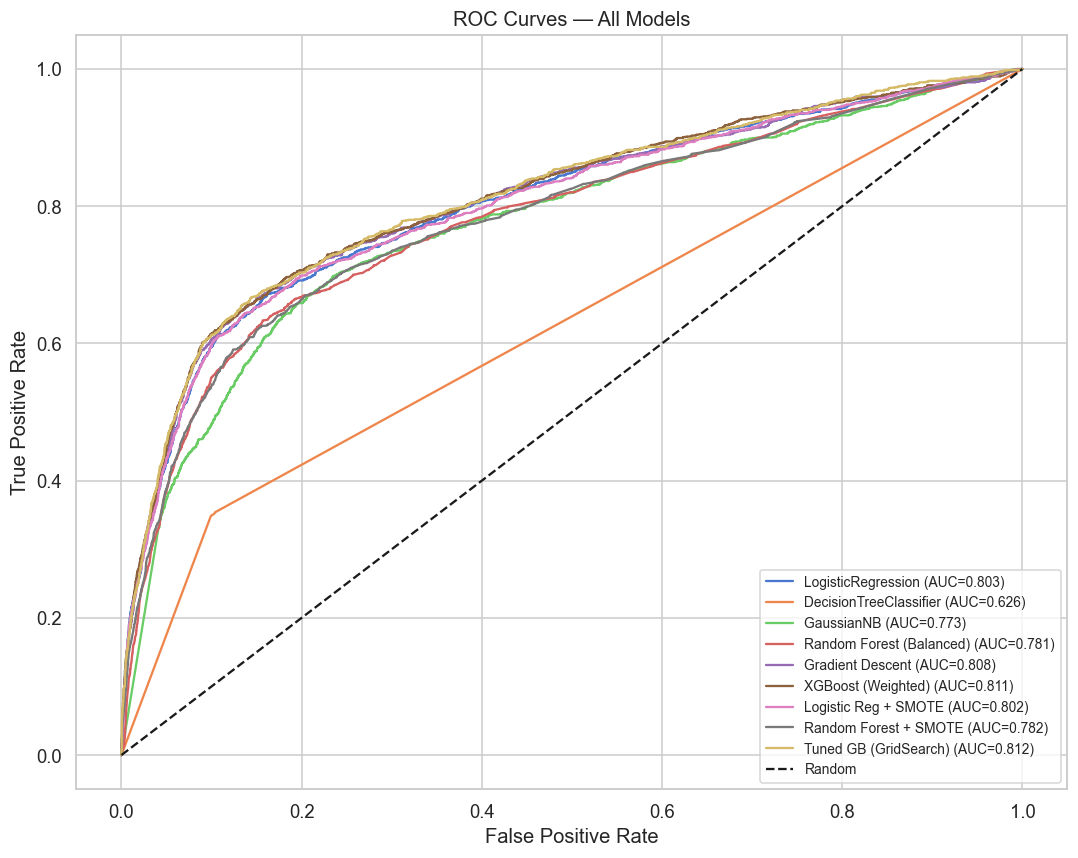

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))

for name, ypr in prob.items():
    if ypr is not None:
        # Check if ypr is 2D. If so, grab the second column. Otherwise, use it as is.
        y_scores = ypr[:, 1] if ypr.ndim == 2 else ypr
        
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc = roc_auc_score(y_test, y_scores)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.4 - Confusion Matrix

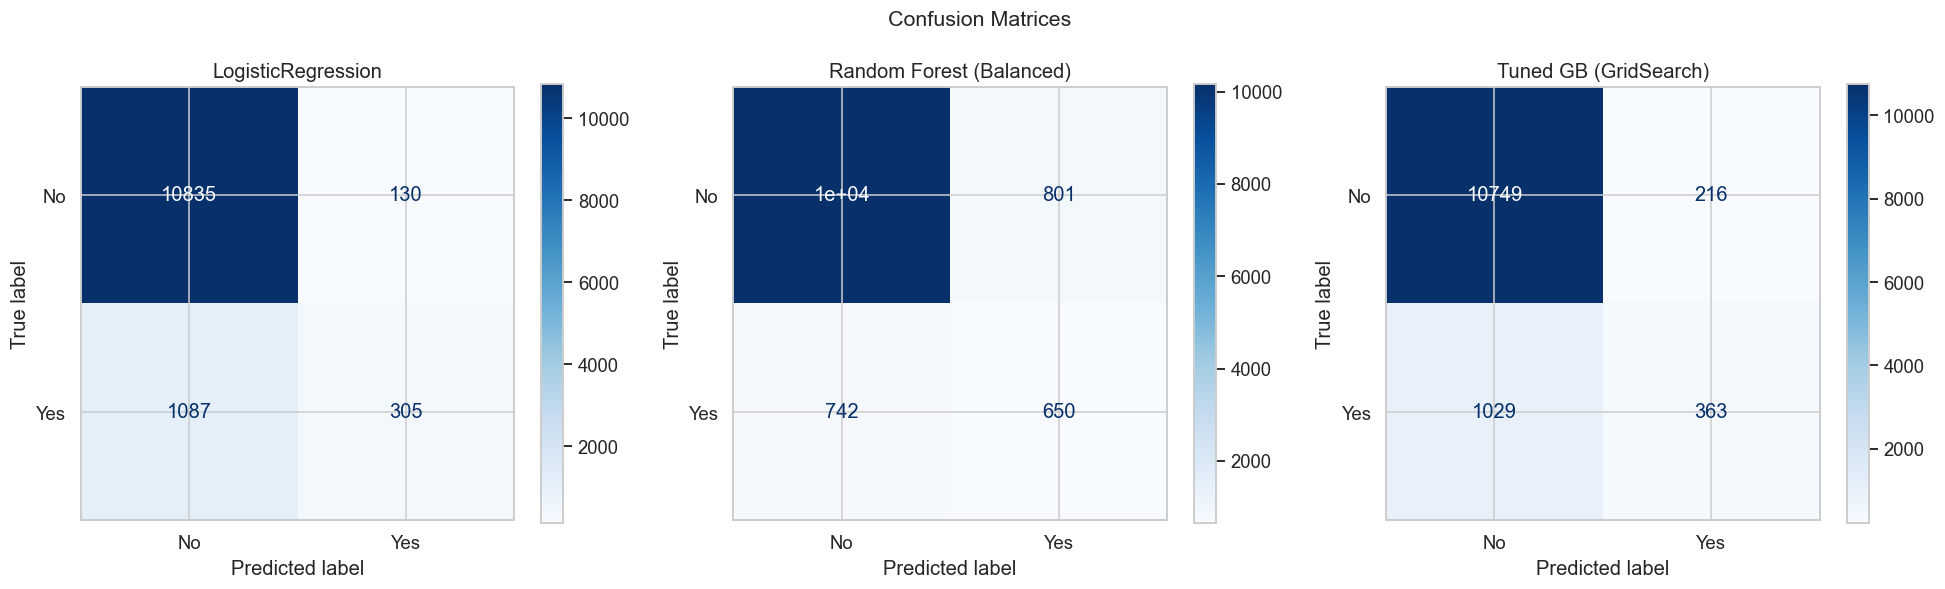

In [56]:
key_models = ['LogisticRegression', 'Random Forest (Balanced)', 'Tuned GB (GridSearch)']

fig, axes = plt.subplots(1, len(key_models), figsize=(6 * len(key_models), 5))

for ax, name in zip(axes, key_models):
    cm = confusion_matrix(y_test, pred[name])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.5 - Feature Importance - Best Model

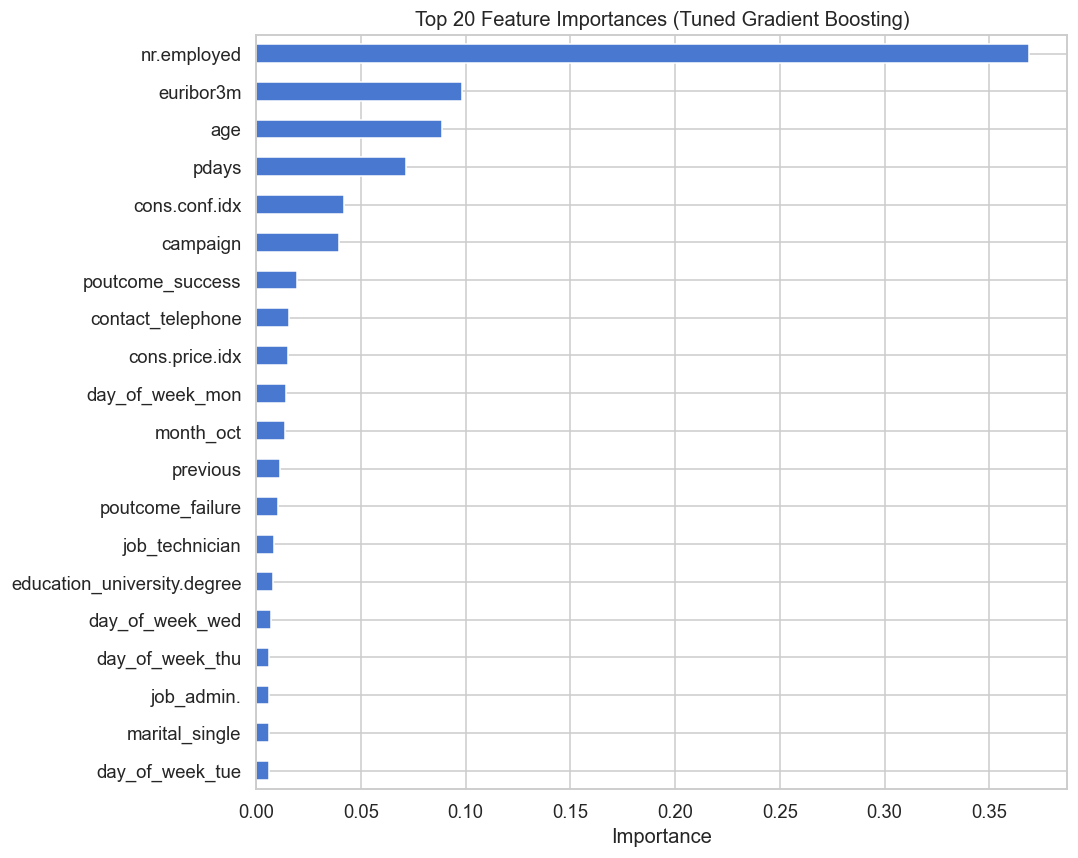

In [57]:
ohe_features = best_model.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_col_model)
feature_names = np.concatenate([num_col_model, ohe_features])

importances = best_model.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', ax=ax)
ax.set_title('Top 20 Feature Importances (Tuned Gradient Boosting)')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.6 Error Analysis

In [58]:
X_test_analysis = x_test.copy()
X_test_analysis['y_true'] = y_test.values
X_test_analysis['y_pred'] = y_pred_best
X_test_analysis['y_prob'] = y_prob_best

fn = X_test_analysis[(X_test_analysis['y_true'] == 1) & (X_test_analysis['y_pred'] == 0)]
fp = X_test_analysis[(X_test_analysis['y_true'] == 0) & (X_test_analysis['y_pred'] == 1)]

print(f'False Negatives (missed subscribers): {len(fn)}')
print(f'False Positives (wrongly predicted as subscriber): {len(fp)}')

print('\n--- False Negatives: Summary ---')
print(fn[num_col_model].describe().round(2))
print('\n--- False Negatives: Top Job Types ---')
print(fn['job'].value_counts().head(5))

False Negatives (missed subscribers): 1029
False Positives (wrongly predicted as subscriber): 216

--- False Negatives: Summary ---
           age  campaign    pdays  previous  emp.var.rate  cons.price.idx  \
count  1029.00   1029.00  1029.00   1029.00       1029.00         1029.00   
mean     39.94      2.20   954.59      0.23         -1.04           93.27   
std      12.95      2.01   205.37      0.56          1.74            0.64   
min      17.00      1.00     1.00      0.00         -3.40           92.20   
25%      31.00      1.00   999.00      0.00         -1.80           92.89   
50%      37.00      2.00   999.00      0.00         -1.80           93.08   
75%      47.00      3.00   999.00      0.00          1.10           93.92   
max      88.00     23.00   999.00      5.00          1.40           94.77   

       cons.conf.idx  euribor3m  nr.employed  
count        1029.00    1029.00      1029.00  
mean          -40.48       2.45      5120.66  
std             6.07       1.80  

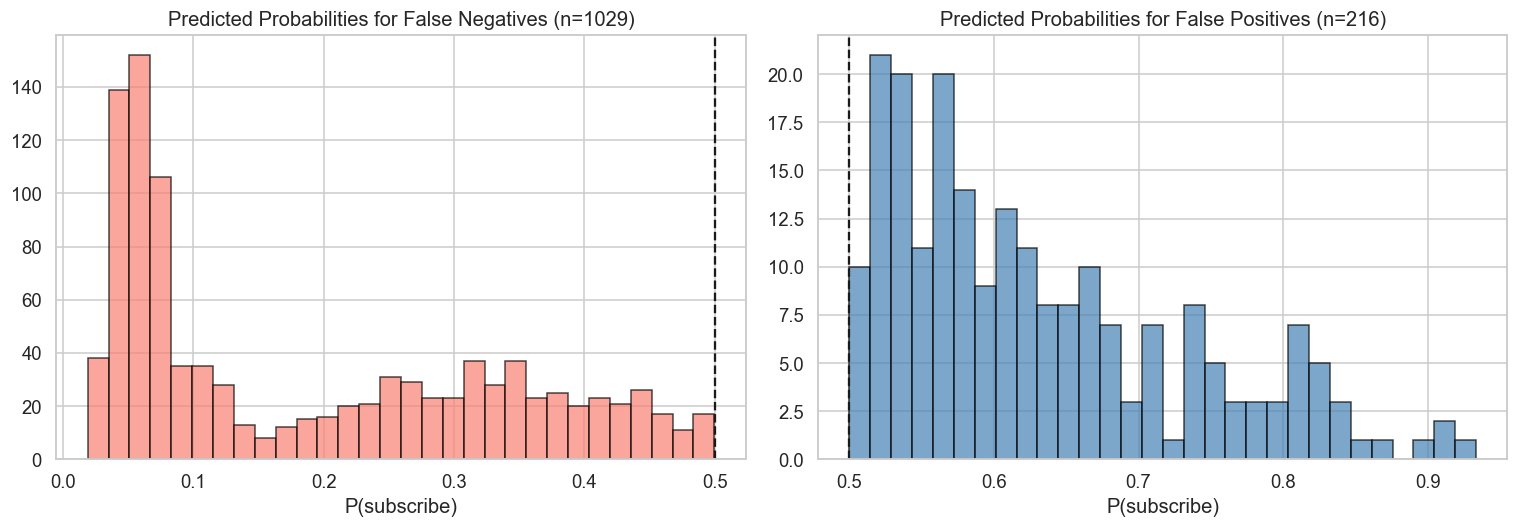

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fn['y_prob'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
axes[0].set_title(f'Predicted Probabilities for False Negatives (n={len(fn)})')
axes[0].set_xlabel('P(subscribe)')
axes[0].axvline(x=0.5, color='k', linestyle='--')

axes[1].hist(fp['y_prob'], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[1].set_title(f'Predicted Probabilities for False Positives (n={len(fp)})')
axes[1].set_xlabel('P(subscribe)')
axes[1].axvline(x=0.5, color='k', linestyle='--')

plt.tight_layout()
plt.show()

**Error Analysis Observations:**
- Most false negatives have predicted probabilities just below the 0.5 threshold — a lower threshold could capture more subscribers at the cost of more false positives.
- A cost-sensitive threshold adjustment could be valuable if the business cost of missing a subscriber is higher than a wasted call.

---
## 6 — Conclusions

1. **Best model:** The tuned Gradient Boosting achieved the highest ROC-AUC on the held-out test set, demonstrating strong discriminative ability.
2. **Class imbalance:** Using `class_weight='balanced'` and `scale_pos_weight` improved recall for the minority class substantially compared to default settings. SMOTE provided comparable improvements.
3. **Key predictive features:** Macroeconomic indicators (`euribor3m`, `nr.employed`, `emp.var.rate`), contact type, and number of previous campaign contacts were among the top predictors — more important than demographic features alone.
4. **Duration excluded:** As noted in the dataset documentation, `duration` was dropped to build a realistic predictive model. Including it would inflate performance artificially.
5. **Practical recommendation:** For a marketing campaign, optimising recall (capturing as many potential subscribers as possible) at the expense of some false positives is likely the right trade-off, given that the cost of a phone call is low relative to the revenue from a new term deposit subscription. A threshold below 0.5 could be tuned using the precision-recall curve.